# הדגמת מודלים לינאריים על MovieLens

מחברת זו מדגימה בסיס ייחוס נקי ו**דטרמיניסטי** לחיזוי דירוג ממוצע של סרטים באמצעות מודלים לינאריים פשוטים:

- **הורדת** מאגר הנתונים *ml-latest-small* של MovieLens
- בניית **פיצ'רים ברמת סרט** (ספירות, שנים, ז'אנרים בקידוד one-hot)
- חלוקה **אקראית לאימון/ולידציה/בדיקה** (עם זרע קבוע)
- אימון **לינארי**, **Ridge** (α=0.1), **Lasso** (α=0.001) — *ללא חיפוש רשת*
- **פרשנות מקדמים** להבנת השפעת פיצ'רים
- **חלוקה לפי זמן** להצגת תרחיש ריאליסטי יותר

> טיפ: זוהי הדגמה ברמת *סרט*. מערכות המלצה אמיתיות עובדות ברמת משתמש-סרט ומרוויחות מפיצ'רים שיתופיים (גורמי משתמש/סרט).

## 0. הגדרות ועזרים

In [118]:
import os, io, zipfile, math, re, json, textwrap
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from datetime import datetime

np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 200)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def r2_rmse(y_true, y_pred):
    return r2_score(y_true, y_pred), rmse(y_true, y_pred)


## 1. הורדת MovieLens (ml-latest-small)
אם הקבצים כבר קיימים מקומית, שלב זה ידלג על ההורדה.

In [119]:
import requests

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
ZIP_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP_PATH = DATA_DIR / "ml-latest-small.zip"
EXTRACT_DIR = DATA_DIR / "ml-latest-small"

if not EXTRACT_DIR.exists():
    if not ZIP_PATH.exists():
        print("Downloading:", ZIP_URL)
        r = requests.get(ZIP_URL, timeout=60)
        r.raise_for_status()
        ZIP_PATH.write_bytes(r.content)
        print("Saved:", ZIP_PATH)

    print("Extracting:", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Extracted to:", EXTRACT_DIR)
else:
    print("Already available:", EXTRACT_DIR)

# Load CSVs
ratings = pd.read_csv(EXTRACT_DIR / "ratings.csv")
movies  = pd.read_csv(EXTRACT_DIR / "movies.csv")

print("ratings:", ratings.shape, "| movies:", movies.shape)
display(ratings.head())
display(movies.head())


Already available: data\ml-latest-small
ratings: (100836, 4) | movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. בניית פיצ'רים ברמת סרט

אנו מצברים **דירוגים** לפי `movieId` לחישוב:
- `avg_rating` : דירוג ממוצע
- `n_ratings` : מספר הדירוגים
- `first_year`, `last_year` : שנת הדירוג המינימלית/מקסימלית (מ-timestamps)
- `rating_span` : last_year - first_year


אנו גם מבצעים קידוד one-hot לעמודת **הז'אנרים** מ-`movies.csv`.

In [120]:
# Convert timestamps to years for first/last rating year
ratings["year"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.year

agg = ratings.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    n_ratings=("rating", "size"),
    first_year=("year", "min"),
    last_year=("year", "max"),
).reset_index()

# add a feature for the rating span (last_year - first_year)
agg["rating_span"] = agg["last_year"] - agg["first_year"]

# Genres one-hot
def split_genres(g):
    if pd.isna(g) or g == "(no genres listed)":
        return []
    return g.split("|")

genre_sets = movies["genres"].apply(split_genres)
unique_genres = sorted(set(g for s in genre_sets for g in s))
# Remove empty label if present
unique_genres = [g for g in unique_genres if g and g != "(no genres listed)"]

genre_mat = {f"genre_{g}": [] for g in unique_genres}
for gs in genre_sets:
    gs_set = set(gs)
    for g in unique_genres:
        genre_mat[f"genre_{g}"].append(g in gs_set)

genre_df = pd.DataFrame(genre_mat)
movies_expanded = pd.concat([movies[["movieId", "title"]], genre_df], axis=1)

# Merge features
movie_features = agg.merge(movies_expanded, on="movieId", how="left")

# Optional: extract release year from title "(YYYY)"
def extract_release_year(title):
    m = re.search(r"\((\d{4})\)", str(title))
    return int(m.group(1)) if m else np.nan

movie_features["release_year"] = movie_features["title"].apply(extract_release_year)

display(movie_features.head())
print(movie_features.shape)


,movieId,avg_rating,n_ratings,first_year,last_year,rating_span,title,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,release_year
0,1,3.920930,215,1996,2018,22,Toy Story (1995),False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,1995.0
1,2,3.431818,110,1996,2018,22,Jumanji (1995),False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,1995.0
2,3,3.259615,52,1996,2017,21,Grumpier Old Men (1995),False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1995.0
3,4,2.357143,7,1996,2009,13,Waiting to Exhale (1995),False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,1995.0
4,5,3.071429,49,1996,2018,22,Father of the Bride Part II (1995),False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1995.0


(9724, 27)


## 3. מטריצת פיצ'רים (X) ומשתנה יעד (y)

אנו משתמשים במנבאים נומריים:
- `n_ratings_log1p` (ספירה בהמרת לוג)    &nbsp; &nbsp; &nbsp; למה זה שימושי? &nbsp; &nbsp;  גלה בעצמך!
- `first_year`
- `last_year`
- `rating_span`

…וכל עמודות `genre_*` בקידוד one-hot.

יעד: **`avg_rating`**.

In [121]:
target_col = "avg_rating"
num_cols = ["n_ratings", "first_year", "last_year", "rating_span"]
genre_cols = [c for c in movie_features.columns if c.startswith("genre_")]

X = movie_features[num_cols + genre_cols].copy()
X["n_ratings_log1p"] = np.log1p(X["n_ratings"])
feature_cols = ["n_ratings_log1p", "first_year", "last_year", "rating_span"] + genre_cols
X = X[feature_cols]
y = movie_features[target_col].copy()

print("X shape:", X.shape, "| y shape:", y.shape)
display(X.head())


X shape: (9724, 23) | y shape: (9724,)


,n_ratings_log1p,first_year,last_year,rating_span,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,5.375278,1996,2018,22,False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,4.709530,1996,2018,22,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,3.970292,1996,2017,21,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,2.079442,1996,2009,13,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False
4,3.912023,1996,2018,22,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 4. חלוקה אקראית לאימון / בדיקה

- חלוקה אקראית `train/test` (80/20).
- אימון **לינארי**, **Ridge (α=0.1)**, **Lasso (α=0.001)** — ערכי alpha קבועים לבסיס ייחוס פשוט וניתן לשחזור.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np, pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree

# --- split only into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=None
)  # note: to use the same split, set the same random_state!

# --- columns: scale numeric only; passthrough genre_* ---
num_cols = ["n_ratings_log1p", "first_year", "last_year", "rating_span"]
cat_cols = [c for c in X.columns if c.startswith("genre_")]


pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),  # scale numeric
        ("cat", "passthrough", cat_cols),     # keep booleans as-is
    ],
    remainder="drop"
)

# --- fixed alphas ---
RIDGE_ALPHA = 0.1
LASSO_ALPHA = 0.001

# --- build pipelines & fit on TRAIN ---
lin_full   = Pipeline([("pre", pre), ("model", LinearRegression())]).fit(X_train, y_train)
ridge_full = Pipeline([("pre", pre), ("model", Ridge(alpha=RIDGE_ALPHA))]).fit(X_train, y_train)
lasso_full = Pipeline([("pre", pre), ("model", Lasso(alpha=LASSO_ALPHA, max_iter=20000))]).fit(X_train, y_train)

# no need to normalize for trees, but it will not hurt either.
# It is used here just because we want to reuse the same preprocessor for all models.
# The max_depth=6 is a simple regularization to prevent overfitting on this dataset.
tree_full  = Pipeline([("pre", pre), ("model", DecisionTreeRegressor(random_state=42,max_depth=6))]).fit(X_train, y_train)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))



def metrics_row(pipe, Xtrain, ytrain, Xtest, ytest):
    ytrain_p = pipe.predict(Xtrain)
    ytest_p = pipe.predict(Xtest)
    return {
        "R2_train": r2_score(ytrain, ytrain_p),
        "RMSE_train": rmse(ytrain, ytrain_p),
        "R2_test": r2_score(ytest, ytest_p),
        "RMSE_test": rmse(ytest, ytest_p),
    }

# --- build “sweep-style” single-row tables (train/test only) ---
linear_m = metrics_row(lin_full, X_train, y_train, X_test, y_test)
linear_table = pd.DataFrame([{"Alpha": None, **linear_m}])  # ** unpack dict into row

ridge_m = metrics_row(ridge_full, X_train, y_train, X_test, y_test)
ridge_table = pd.DataFrame([{"Alpha": RIDGE_ALPHA, **ridge_m}])  

lasso_m = metrics_row(lasso_full, X_train, y_train, X_test, y_test)
lasso_table = pd.DataFrame([{"Alpha": LASSO_ALPHA, **lasso_m}])

tree_m = metrics_row(tree_full, X_train, y_train, X_test, y_test)
tree_table = pd.DataFrame([{"Alpha": None, **tree_m}])

# --- summary table (test only) ---
lin_m = metrics_row(lin_full, X_train, y_train, X_test, y_test)
summary = pd.DataFrame([
    {"Model": "Linear",                   "Alpha": None,
     "R2_test": lin_m["R2_test"],   "RMSE_test": lin_m["RMSE_test"]},
    {"Model": f"Ridge (α={RIDGE_ALPHA})", "Alpha": RIDGE_ALPHA,
     "R2_test": ridge_m["R2_test"], "RMSE_test": ridge_m["RMSE_test"]},
    {"Model": f"Lasso (α={LASSO_ALPHA})", "Alpha": LASSO_ALPHA,
     "R2_test": lasso_m["R2_test"], "RMSE_test": lasso_m["RMSE_test"]},
    {"Model": "Regression Tree", "Alpha": None,
     "R2_test": tree_m["R2_test"],  "RMSE_test": tree_m["RMSE_test"]},
])

print("— Linear Regression —")
display(linear_table.round(4))
print("— Ridge alpha sweep —")
display(ridge_table.round(4))
print("— Lasso alpha sweep —")
display(lasso_table.round(4))
print("— Regression Tree —")
display(tree_table.round(4))

print("— Summary (Test) —")
display(summary.sort_values("RMSE_test").round(4))




— Linear Regression —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,None,0.1184,0.8206,0.1263,0.8038


— Ridge alpha sweep —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,0.1,0.1184,0.8206,0.1263,0.8038


— Lasso alpha sweep —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,0.001,0.1179,0.8208,0.1257,0.8041


— Regression Tree —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,None,0.162,0.8,0.0825,0.8237


— Summary (Test) —


,Model,Alpha,R2_test,RMSE_test
1,Ridge (α=0.1),0.100,0.1263,0.8038
0,Linear,NaN,0.1263,0.8038
2,Lasso (α=0.001),0.001,0.1257,0.8041
3,Regression Tree,NaN,0.0825,0.8237


<div style="background-color: black; padding: 20px;"><b>שאלה:</b> <br>האם ה-RMSE של סט הבדיקה יכול להיות קטן מה-RMSE של סט האימון? <br>&nbsp; &nbsp; עיין בתיעוד של DecisionTreeRegressor, או חפש במקור אחר. <br> ישנן מספר סיבות אפשריות לתופעה כזו:<br> 1. שונות אקראית בחלוקת האימון/בדיקה, במיוחד עם מאגר נתונים קטן. <br>    כדי לבדוק זאת, ניתן לנסות זרעים אקראיים שונים לחלוקה ולראות אם הדפוס נשמר.<br> 2. סט הבדיקה עשוי להיות במקרה קל יותר לחיזוי מסט האימון, מה שמוביל ל-RMSE נמוך יותר.<br>    כדי לבדוק זאת, ניתן לבחון את ההתפלגות של משתנה היעד בשני הסטים ולראות אם סט הבדיקה אכן קל יותר.<br>    שימוש בזרע אקראי שונה עשוי לפתור בעיה זו.<br> 3. ברגולריזציה, ייתכן שה-RMSE של המודל המרוסן יהיה קטן יותר על הבדיקה<br>    מאשר על האימון, מכיוון שהרגולריזציה אינה מוחלת על סט הבדיקה.<br> 4. סיבות נוספות שיכולות לגרום לכך בכלל:<br>    - דליפת נתונים (data leakage) מהאימון לבדיקה.<br>    - התאמת חסר (underfitting) — המודל פשוט מדי. שוב, כדי לבדוק, נסה זרע אקראי שונה.<br> באופן כללי, עדיף להשתמש ב-cross-validation לקבלת הערכה אמינה יותר של ביצועי הבדיקה,<br>  במיוחד עם מאגרי נתונים קטנים. נסה זאת!<br> כמו כן, השווה את התנהגות רגרסיית העץ למודלים הלינאריים מבחינת ביצועי אימון/בדיקה ו-overfitting.</div>

<div style="background-color: black; padding: 20px;"><b>שאלה:</b> <br>האם סט הבדיקה עבר נורמליזציה? <br>האם עלינו לטפל בכך?<div>

In [ ]:
# The ColumnTransformer and Pipeline handle this automatically.
# When you call `fit` on the training data, the scaler learns the mean and standard deviation.
# When you call `predict` on the test data, the scaler uses the same mean and standard deviation to transform the test data.

# to demonatrate this, we get from the lin_full pipeline the values of the transformation that the
# standard scaler found on the train set, and print it:
scaler = lin_full.named_steps["pre"].named_transformers_["num"]
print("Mean:", scaler.mean_)
print("Scale:", scaler.scale_)
print()

# now apply the same transformation to the test set and print the first 5 rows:
X_test_scaled = scaler.transform(X_test[num_cols])

# show mean and std of each feature for the original test set and the scaled test set:
print("Mean of original test set:")
print(X_test[num_cols].mean())
print()
print("Std of original test set:")
print(X_test[num_cols].std())
print()
print("Mean of scaled test set:") # should be close to 0 for all features
print(X_test_scaled.mean(axis=0))   
print()
print("Std of scaled test set:") # should be close to 1 for all features
print(X_test_scaled.std(axis=0))   
print()

# no need to normalize for trees, but it will not hurt either.
# It is used here just because we want to reuse the same preprocessor for all models.

Mean: [   1.64966935 2006.88025272 2013.43476344    6.55451073]
Scale: [1.07285735 7.14771526 5.78836947 7.34794212]

Mean of original test set:
n_ratings_log1p       1.656591
first_year         2006.705278
last_year          2013.323509
rating_span           6.618232
dtype: float64

Std of original test set:
n_ratings_log1p    1.077130
first_year         7.117278
last_year          5.765103
rating_span        7.345313
dtype: float64

Mean of scaled test set:
[ 0.00645173 -0.02447987 -0.0192203   0.00867194]

Std of scaled test set:
[1.00381062 0.99557111 0.99580976 0.99947087]



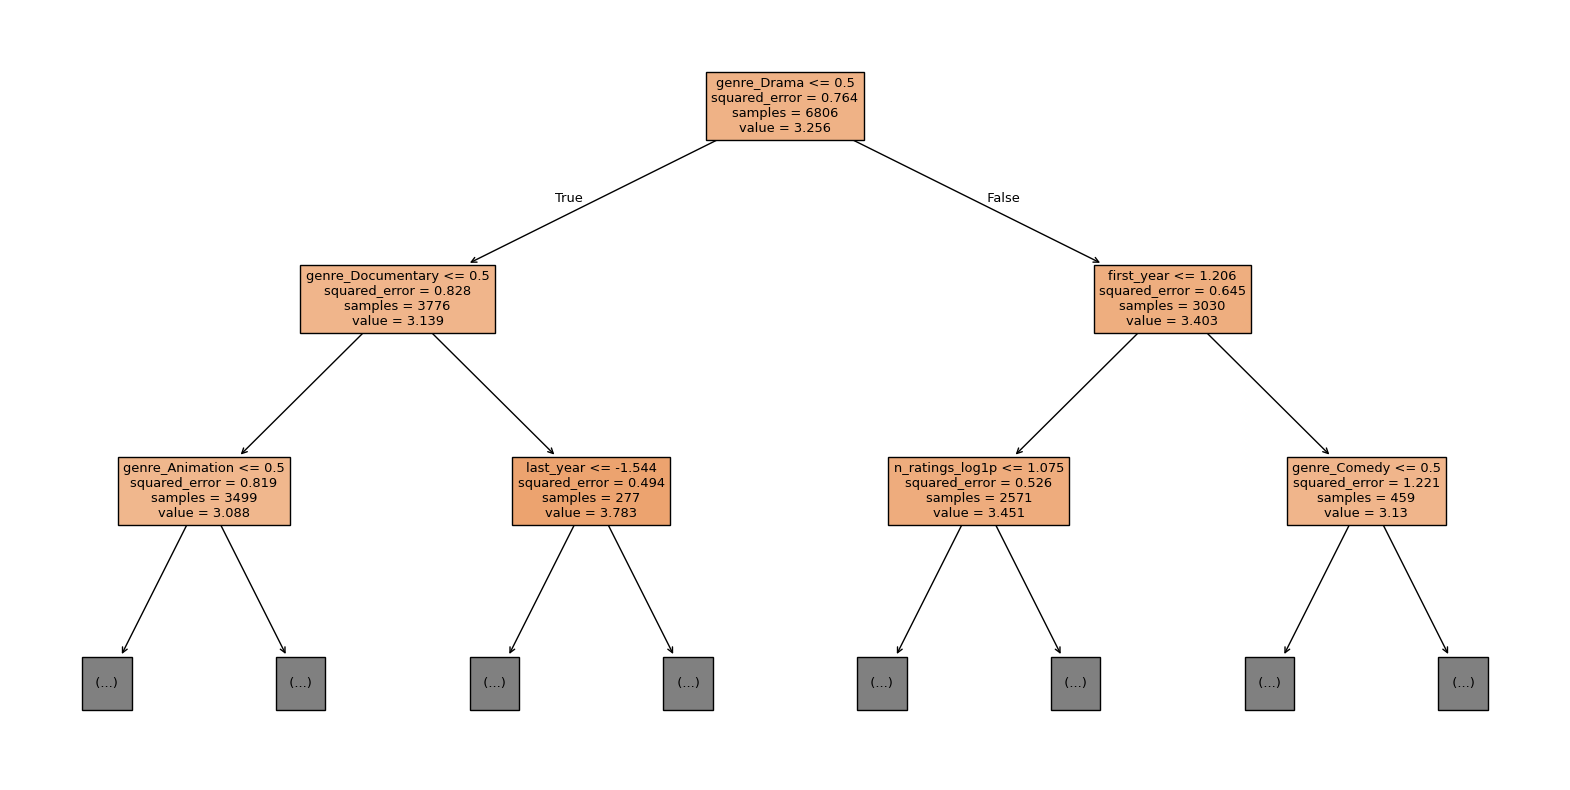

In [124]:
# show the tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree_full.named_steps["model"], feature_names=feature_cols, filled=True, max_depth=2)
plt.show()

<div style="background-color: black; padding: 20px;"><b>שאלה:</b> <br>1. כיצד רגרסיית העץ מנבאת? <br>&nbsp; &nbsp; עיין בתיעוד של DecisionTreeRegressor, או חפש במקור אחר. <br>2. כיצד עומק מקסימלי של העץ משפיע על רמת הגרנולריות של החיזוי?</div>

## 5. פרשנות מקדמים

גודל המקדמים משקף את השפעת הפיצ'רים **תחת הנחות המודל**.
במודלים לינאריים עם פיצ'רים בסולמות שונים, לא ניתן להשוות גודל ישירות אלא אם הפיצ'רים עוברים תקנון.
כאן, לפיצ'רים נומריים יש סולם שונה מהמשתנים הבינאריים (`genre_*`), לכן יש להשוות כיוונים וגדלים יחסיים בזהירות.

> בהדגמות, נהוג לתקנן פיצ'רים נומריים לפני Ridge/Lasso.

In [125]:
def coef_df(pipeline, cols):
    # For pipelines, we need to access the model inside the pipeline
    if hasattr(pipeline, 'named_steps'):
        # It's a pipeline - get the model from the 'model' step
        model = pipeline.named_steps['model']
    else:
        # It's a direct model
        model = pipeline
    
    coef = getattr(model, "coef_", None)
    if coef is None:
        return pd.DataFrame({"feature": cols, "coef": np.nan})
    return pd.DataFrame({"feature": cols, "coef": coef}).sort_values("coef", ascending=False)

cols = X.columns.tolist()

print("Top positive coefficients (Linear):")
display(coef_df(lin_full, cols).head(10))

print("Top negative coefficients (Linear):")
display(coef_df(lin_full, cols).tail(10))


Top positive coefficients (Linear):


,feature,coef
10,genre_Documentary,0.649318
6,genre_Animation,0.509535
13,genre_Film-Noir,0.311398
0,n_ratings_log1p,0.275633
21,genre_War,0.255402
11,genre_Drama,0.246522
22,genre_Western,0.142100
1,first_year,0.081795
9,genre_Crime,0.070215
18,genre_Romance,0.069211


Top negative coefficients (Linear):


,feature,coef
5,genre_Adventure,-0.013330
2,last_year,-0.030211
8,genre_Comedy,-0.059818
19,genre_Sci-Fi,-0.072728
3,rating_span,-0.103365
20,genre_Thriller,-0.122359
15,genre_IMAX,-0.124196
14,genre_Horror,-0.169235
4,genre_Action,-0.213622
7,genre_Children,-0.270826


In [126]:
# show the tree best features
tree_model = tree_full.named_steps["model"]
feature_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)
print("Top features by importance (Tree):")
display(feature_importances.head(10))

Top features by importance (Tree):


,feature,importance
0,n_ratings_log1p,0.157764
1,first_year,0.155986
10,genre_Documentary,0.147108
11,genre_Drama,0.139009
6,genre_Animation,0.104385
8,genre_Comedy,0.070378
2,last_year,0.054995
4,genre_Action,0.036405
14,genre_Horror,0.019356
16,genre_Musical,0.019122


In [127]:
# Get the model from the pipeline
linear_model = lin_full.named_steps['model']
intercept = linear_model.intercept_
coefficients = linear_model.coef_

# Create the formula string
formula_parts = [f"{intercept:.4f}"]  # Start with intercept

for i, (feature, coef) in enumerate(zip(cols, coefficients)):
    if coef != 0:  # Only include non-zero coefficients
        sign = "+" if coef >= 0 else ""
        formula_parts.append(f"{sign}{coef:.4f} * {feature}")

formula = " + ".join(formula_parts)
print("Linear Regression Formula:")
print(f"avg_rating = {formula}")



Linear Regression Formula:
avg_rating = 3.1817 + +0.2756 * n_ratings_log1p + +0.0818 * first_year + -0.0302 * last_year + -0.1034 * rating_span + -0.2136 * genre_Action + -0.0133 * genre_Adventure + +0.5095 * genre_Animation + -0.2708 * genre_Children + -0.0598 * genre_Comedy + +0.0702 * genre_Crime + +0.6493 * genre_Documentary + +0.2465 * genre_Drama + -0.0075 * genre_Fantasy + +0.3114 * genre_Film-Noir + -0.1692 * genre_Horror + -0.1242 * genre_IMAX + -0.0116 * genre_Musical + +0.0683 * genre_Mystery + +0.0692 * genre_Romance + -0.0727 * genre_Sci-Fi + -0.1224 * genre_Thriller + +0.2554 * genre_War + +0.1421 * genre_Western


## 6. חלוקה לפי זמן

במקום חלוקה אקראית, אנו מחלקים לפי **שנת הדירוג הראשון** (`first_year`) כדי לדמות אימון על סרטים *ישנים יותר* ובדיקה על סרטים *חדשים יותר*.
נבחר שנת חסך כ**אחוזון ה-80** של `first_year` (ניתן לשנות זאת).

> הערה: מכיוון ש-`avg_rating` מצבר *את כל* הדירוגים, קיימת דליפה מסוימת מדירוגים שלאחר החסך אל תוך היעד. לסביבה סיבתית-זמנית אמיתית, יש לחשב יעדים מ**דירוגים שלפני החסך בלבד**; זה מורכב יותר, ולכן אנו שומרים על פשטות כאן למטרות הדגמה.

In [128]:
# Choose cutoff as 80th percentile of first_year among movies with complete features
mask_complete = (~movie_features["first_year"].isna())
cutoff = int(movie_features.loc[mask_complete, "first_year"].quantile(0.8))
cutoff


2015

In [129]:
# Time-based split
mask_train_time = movie_features["first_year"] <= cutoff
mask_test_time  = movie_features["first_year"]  > cutoff

X_train_time = X.loc[mask_train_time].copy()
y_train_time = y.loc[mask_train_time].copy()
X_test_time  = X.loc[mask_test_time].copy()
y_test_time  = y.loc[mask_test_time].copy()

print("Cutoff year:", cutoff)
print("Train_time:", X_train_time.shape, "| Test_time:", X_test_time.shape)

# Fit fixed-alpha models
lin_t   = LinearRegression().fit(X_train_time, y_train_time)
ridge_t = Ridge(alpha=0.1).fit(X_train_time, y_train_time)
lasso_t = Lasso(alpha=0.001, max_iter=20000).fit(X_train_time, y_train_time)

# Evaluate
def eval_row(name, model, Xtr, ytr, Xte, yte):
    ytr_p = model.predict(Xtr)
    yte_p = model.predict(Xte)
    return {
        "Model": name,
        "Train RMSE": rmse(ytr, ytr_p),
        "Train R2": r2_score(ytr, ytr_p),
        "Test RMSE": rmse(yte, yte_p),
        "Test R2": r2_score(yte, yte_p),
    }

rows_time = [
    eval_row("Linear (time)", lin_t, X_train_time, y_train_time, X_test_time, y_test_time),
    eval_row("Ridge α=0.1 (time)", ridge_t, X_train_time, y_train_time, X_test_time, y_test_time),
    eval_row("Lasso α=0.001 (time)", lasso_t, X_train_time, y_train_time, X_test_time, y_test_time),
]
pd.DataFrame(rows_time).round(4)


Cutoff year: 2015
Train_time: (7789, 23) | Test_time: (1935, 23)


,Model,Train RMSE,Train R2,Test RMSE,Test R2
0,Linear (time),0.7224,0.1686,1.1236,0.0079
1,Ridge α=0.1 (time),0.7224,0.1686,1.1236,0.0079
2,Lasso α=0.001 (time),0.7226,0.1680,1.1236,0.0079


In [130]:
# apply a treeregressor to the same data
from sklearn.tree import DecisionTreeRegressor
tree_t = DecisionTreeRegressor(random_state=42, max_depth=5).fit(X_train_time, y_train_time)
eval_row("Decision Tree (time)", tree_t, X_train_time, y_train_time, X_test_time, y_test_time)


{'Model': 'Decision Tree (time)',
 'Train RMSE': 0.7261661046398786,
 'Train R2': 0.15982871802121035,
 'Test RMSE': 1.1289917061214196,
 'Test R2': -0.0016868339853042258}

דברים נוספים לבדיקה:
האם ישנם פיצ'רים מתואמים? האם זה פוגע במודלים שלנו?

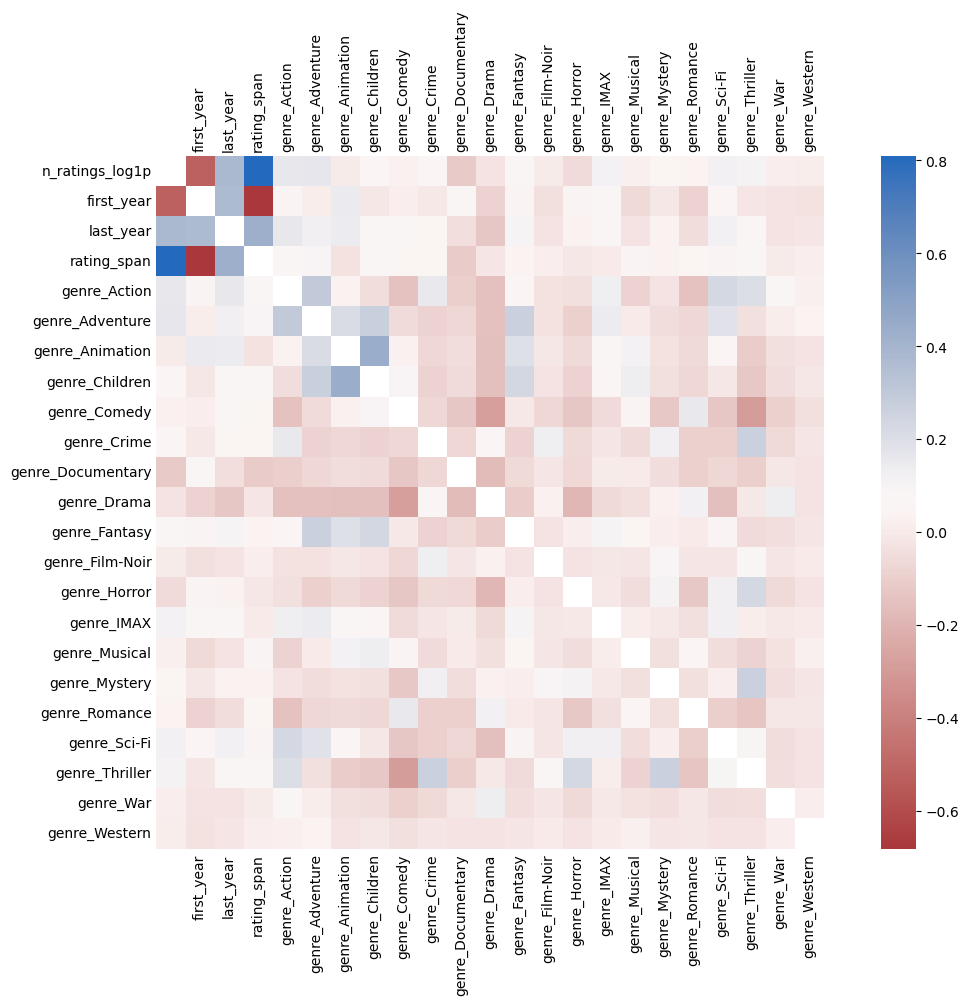

In [131]:
# Are some of the features correlated? does it harm our models?
# How can we check it?
import seaborn as sns
import matplotlib.pyplot as plt

# lets see how each feature correlates to the others.


# first transform all non numeric features to numeric (the genres)
# this may not be useful, but let's see what we get.
X_corr = X.copy()
for c in X_corr.columns:
    if X_corr[c].dtype == "bool":
        X_corr[c] = X_corr[c].astype(int)   
corr_matrix = X_corr.corr()

# remove the diagonal elements (correlation of a feature with itself) to make the heatmap easier to read
np.fill_diagonal(corr_matrix.values, np.nan)

plt.figure(figsize=(11, 9))
ax = sns.heatmap(corr_matrix, annot=False, cmap="vlag_r")

#ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticks(np.arange(corr_matrix.shape[1]) + 1.5, minor=False)
#ax.xaxis.tick_top()
#ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', which='major', labelbottom=True, labeltop=True, bottom=True, top=True)

plt.xticks(rotation=90, ha='center') # ha='center' handles alignment
ax.tick_params(axis='both', which='both', length=0)

plt.show()  





n_ratings_log1p & rating_span: 0.81
first_year & rating_span: -0.68
n_ratings_log1p & first_year: -0.52
genre_Animation & genre_Children: 0.44
last_year & rating_span: 0.43
n_ratings_log1p & last_year: 0.38
first_year & last_year: 0.37


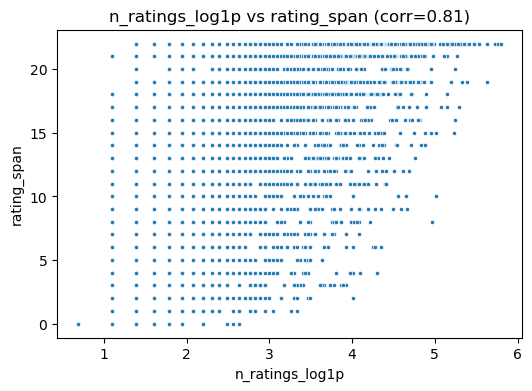

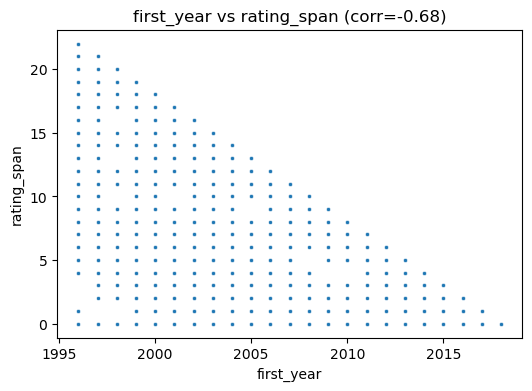

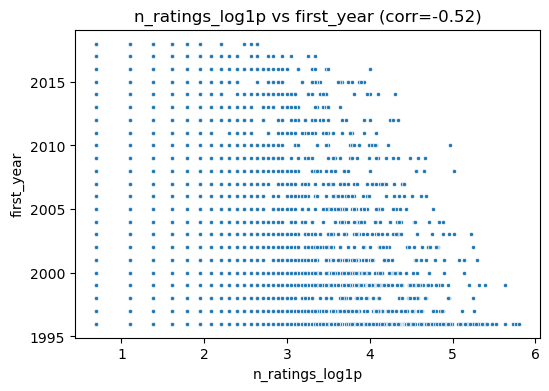

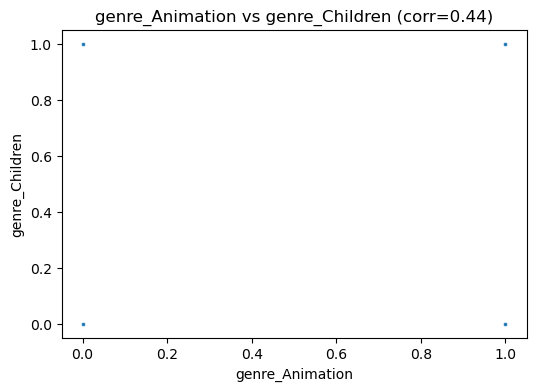

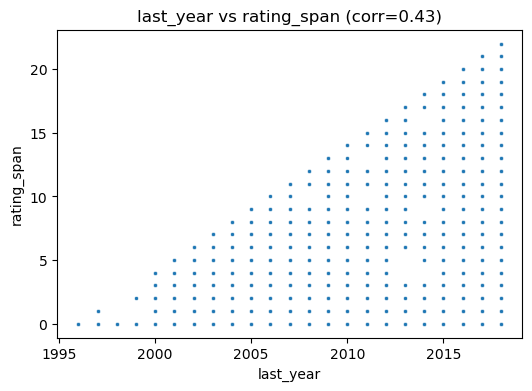

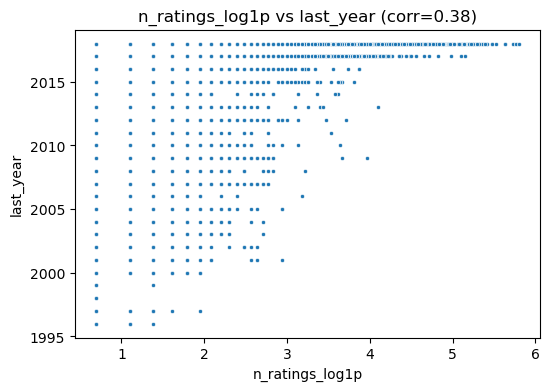

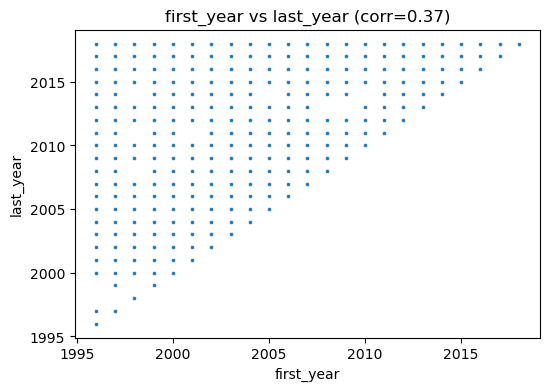

In [132]:
# now using the correlation matrix, find all couples of features that have correlation above abs (threshold), and print them in a readable format (feature1, feature2, correlation_value)
threshold = 0.3
correlated_pairs = []
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[1]):
        corr_value = corr_matrix.iat[i, j]
        if abs(corr_value) > threshold:
            feature1 = corr_matrix.index[i]
            feature2 = corr_matrix.columns[j]
            correlated_pairs.append((feature1, feature2, corr_value))

# sort the correlated pairs by absolute correlation value, descending
correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# print the correlated pairs in a readable format
for feature1, feature2, corr_value in correlated_pairs:
    print(f"{feature1} & {feature2}: {corr_value:.2f}") 

# plot a scatter plot of the all pairs
for feature1, feature2, corr_value in correlated_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X[feature1], y=X[feature2], marker=".")
    plt.title(f"{feature1} vs {feature2} (corr={corr_value:.2f})")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()
        

<div style="background-color: black; padding: 20px;"><b>שאלה:</b> <br>מה דעתך? <br>האם קיימות קורלציות משמעותיות? <br>האם קיימת דרך טובה יותר להמחיש את הקשרים בין משתנים בוליאניים?</div>